# Step 1 — EuroSAT Multispectral Data Exploration

**DEPI AI & Data Science — Project 6: Land Type Classification using Sentinel-2**

This notebook completes the first data-analysis task:
1. Inspect the dataset structure.
2. Identify classes and class counts.
3. Visualize sample images from each class.
4. Inspect the number of spectral bands and image shape.
5. Calculate and visualize mean spectral signatures per class.
6. Calculate basic variability (standard deviation).
7. Optionally calculate NDVI when the required Sentinel-2 bands are available.

> Important: this notebook does **not** change the raw dataset. It only reads it and creates figures/reports.


## 0. Install / import the required libraries

Run this cell first. If a package is missing, install it in the environment rather than changing the raw dataset.


In [ ]:
%pip install numpy pandas matplotlib

  Using cached pandas-3.0.6-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
    --------------------------------------- 0.3/12.7 MB ? eta -:--:--
    --------------------------------------- 0.3/12.7 MB ? eta -:--:--
    ------------

In [1]:
# If needed, uncomment and run:
# %pip install numpy pandas matplotlib seaborn rasterio pillow

import os
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Project root: notebook is expected to be inside <repo>/notebooks/
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
FIGURES = PROJECT_ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data:", DATA_RAW)
print("Figures:", FIGURES)


Project root: C:\Users\HP\Downloads\satellite_empty
Raw data: C:\Users\HP\Downloads\satellite_empty\data\raw
Figures: C:\Users\HP\Downloads\satellite_empty\reports\figures


In [2]:
from pathlib import Path
import zipfile
import urllib.request

PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"

DATA_RAW.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", DATA_RAW)
print("Exists:", DATA_RAW.exists())

Project root: c:\Users\HP\Downloads\satellite_empty
Raw data folder: c:\Users\HP\Downloads\satellite_empty\data\raw
Exists: True


## 1. Inspect `data/raw`

This is the first checkpoint. The notebook searches for common multispectral file formats (`.tif`, `.tiff`, `.npy`) and also checks whether the dataset is organized in class folders.

**Do not move or rename the raw files.**


In [3]:
print("data/raw exists:", DATA_RAW.exists())

if DATA_RAW.exists():
    for p in sorted(DATA_RAW.iterdir()):
        print(("DIR " if p.is_dir() else "FILE"), p.name)
else:
    raise FileNotFoundError(
        f"Could not find {DATA_RAW}. Put the dataset inside data/raw before continuing."
    )


data/raw exists: True
FILE .gitkeep
DIR  EuroSAT_RGB
FILE EuroSAT_RGB.zip


## 2. Discover image files and class folders

For EuroSAT-style datasets, each class is normally represented by a folder. We will infer the class labels from the folder names rather than hard-coding them.


In [4]:
SUPPORTED_EXTENSIONS = {".tif", ".tiff", ".npy", ".npz"}

image_files = []
class_dirs = []

for p in DATA_RAW.rglob("*"):
    if p.is_dir():
        # A directory is considered a class directory if it contains supported image files.
        if any(f.is_file() and f.suffix.lower() in SUPPORTED_EXTENSIONS for f in p.iterdir()):
            class_dirs.append(p)
    elif p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS:
        image_files.append(p)

print("Supported image files found:", len(image_files))
print("Possible class folders found:", len(class_dirs))

if class_dirs:
    print("\nClass folders:")
    for d in sorted(class_dirs):
        n = sum(1 for f in d.iterdir() if f.is_file() and f.suffix.lower() in SUPPORTED_EXTENSIONS)
        print(f"  {d.name}: {n} files")


Supported image files found: 0
Possible class folders found: 0


## 3. Build a dataset index

The index gives us a clean table containing the file path and class label. This is useful later for train/validation/test splitting and reproducible analysis.


In [10]:
from pathlib import Path
import pandas as pd

# Project root
ROOT = Path.cwd().parent

# Dataset location
DATA_DIR = ROOT / "data" / "raw" / "EuroSAT_RGB"

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("Exists:", DATA_DIR.exists())

ROOT: c:\Users\HP\Downloads\satellite_empty
DATA_DIR: c:\Users\HP\Downloads\satellite_empty\data\raw\EuroSAT_RGB
Exists: True


In [11]:
records = []

class_dirs = [p for p in DATA_DIR.iterdir() if p.is_dir()]

print("Number of classes:", len(class_dirs))
print("Classes:", [p.name for p in sorted(class_dirs)])

Number of classes: 1
Classes: ['EuroSAT_RGB']


In [12]:
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}

records = []

if class_dirs:
    for class_dir in sorted(class_dirs):
        label = class_dir.name

        for f in sorted(class_dir.iterdir()):
            if f.is_file() and f.suffix.lower() in SUPPORTED_EXTENSIONS:
                records.append({
                    "path": str(f),
                    "class": label
                })
else:
    # Fallback: if files are not organized in class folders,
    # use the parent folder as a label.
    for f in sorted(DATA_DIR.iterdir()):
        if f.is_file() and f.suffix.lower() in SUPPORTED_EXTENSIONS:
            records.append({
                "path": str(f),
                "class": DATA_DIR.name
            })

print("Total images:", len(records))

Total images: 0


In [14]:
from pathlib import Path

for item in DATA_DIR.iterdir():
    print(item)

c:\Users\HP\Downloads\satellite_empty\data\raw\EuroSAT_RGB\EuroSAT_RGB


In [15]:
DATA_DIR = ROOT / "data" / "raw" / "EuroSAT_RGB" / "EuroSAT_RGB"

print("DATA_DIR:", DATA_DIR)
print("Exists:", DATA_DIR.exists())

DATA_DIR: c:\Users\HP\Downloads\satellite_empty\data\raw\EuroSAT_RGB\EuroSAT_RGB
Exists: True


In [16]:
class_dirs = [p for p in DATA_DIR.iterdir() if p.is_dir()]

print("Number of classes:", len(class_dirs))
print("Classes:", [p.name for p in sorted(class_dirs)])

Number of classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [17]:
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}

records = []

for class_dir in sorted(class_dirs):
    label = class_dir.name

    for f in sorted(class_dir.iterdir()):
        if f.is_file() and f.suffix.lower() in SUPPORTED_EXTENSIONS:
            records.append({
                "path": str(f),
                "class": label
            })

print("Total images:", len(records))

Total images: 27000


In [18]:
df = pd.DataFrame(records)

print(df.head())
print()
print(df["class"].value_counts())

                                                path       class
0  c:\Users\HP\Downloads\satellite_empty\data\raw...  AnnualCrop
1  c:\Users\HP\Downloads\satellite_empty\data\raw...  AnnualCrop
2  c:\Users\HP\Downloads\satellite_empty\data\raw...  AnnualCrop
3  c:\Users\HP\Downloads\satellite_empty\data\raw...  AnnualCrop
4  c:\Users\HP\Downloads\satellite_empty\data\raw...  AnnualCrop

class
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Residential             3000
SeaLake                 3000
Highway                 2500
Industrial              2500
PermanentCrop           2500
River                   2500
Pasture                 2000
Name: count, dtype: int64


In [20]:
from pathlib import Path
import pandas as pd

records = []

# Correct dataset path
DATA_DIR = ROOT / "data" / "raw" / "EuroSAT_RGB" / "EuroSAT_RGB"

if not DATA_DIR.exists():
    raise RuntimeError(f"Dataset folder not found: {DATA_DIR}")

class_dirs = [p for p in DATA_DIR.iterdir() if p.is_dir()]

print("Dataset path:", DATA_DIR)
print("Number of class folders:", len(class_dirs))

for class_dir in sorted(class_dirs):
    label = class_dir.name

    for f in sorted(class_dir.iterdir()):
        if f.is_file() and f.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "path": str(f),
                "class": label
            })

df = pd.DataFrame(records)

if df.empty:
    raise RuntimeError(
        f"No RGB images were found inside {DATA_DIR}. "
        "Check that EuroSAT_RGB is extracted correctly."
    )

print("Total samples:", len(df))
print("Number of classes:", df["class"].nunique())

print("\nClasses:")
print(sorted(df["class"].unique()))

Dataset path: c:\Users\HP\Downloads\satellite_empty\data\raw\EuroSAT_RGB\EuroSAT_RGB
Number of class folders: 10
Total samples: 27000
Number of classes: 10

Classes:
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 4. Class distribution

This checks whether the classes are balanced. We will not remove or duplicate samples at this stage.


,class,count
0,AnnualCrop,3000
1,Forest,3000
2,HerbaceousVegetation,3000
3,Highway,2500
4,Industrial,2500
5,Pasture,2000
6,PermanentCrop,2500
7,Residential,3000
8,River,2500
9,SeaLake,3000


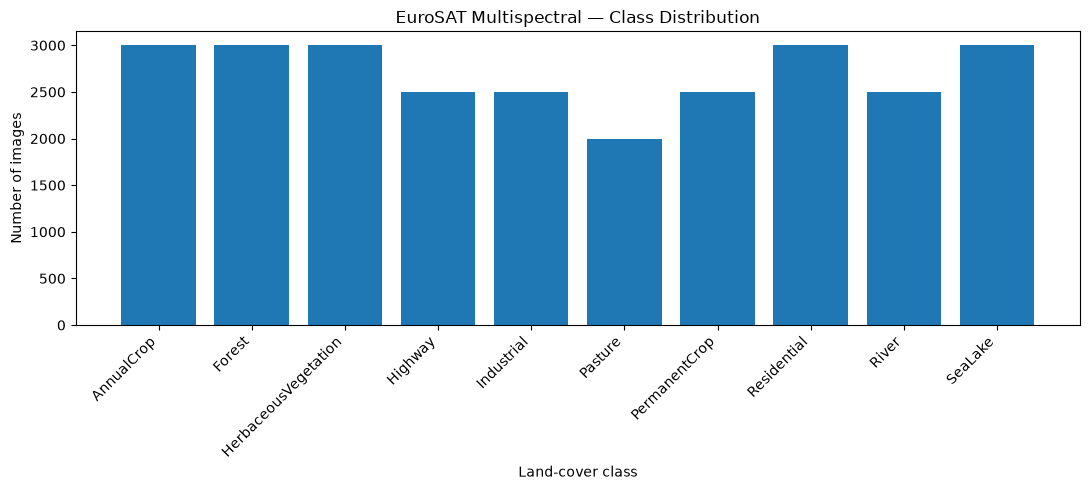

In [21]:
class_counts = (
    df["class"]
    .value_counts()
    .sort_index()
    .rename_axis("class")
    .reset_index(name="count")
)

display(class_counts)

plt.figure(figsize=(11, 5))
plt.bar(class_counts["class"], class_counts["count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Land-cover class")
plt.ylabel("Number of images")
plt.title("EuroSAT Multispectral — Class Distribution")
plt.tight_layout()
plt.savefig(FIGURES / "class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


## 5. Load one multispectral image

The loader supports:
- GeoTIFF (`.tif` / `.tiff`) via `rasterio`
- NumPy arrays (`.npy`)
- NumPy archives (`.npz`)

For a true spectral-signature analysis, the image must contain multiple Sentinel-2 bands. RGB-only data is not sufficient.


In [23]:
from pathlib import Path
import numpy as np
from PIL import Image


def load_multispectral(path):
    path = Path(path)
    suffix = path.suffix.lower()

    # RGB images
    if suffix in {".jpg", ".jpeg", ".png"}:
        image = Image.open(path).convert("RGB")
        arr = np.array(image)
        
        # Convert from (height, width, channels)
        # to (channels, height, width)
        arr = np.transpose(arr, (2, 0, 1))
        
        return arr.astype(np.float32)

    # Multispectral TIFF
    if suffix in {".tif", ".tiff"}:
        try:
            import rasterio
        except ImportError as e:
            raise ImportError(
                "Install rasterio first: %pip install rasterio"
            ) from e

        with rasterio.open(path) as src:
            arr = src.read()

        return arr.astype(np.float32)

    # NumPy array
    if suffix == ".npy":
        arr = np.load(path)
        return arr.astype(np.float32)

    # NumPy archive
    if suffix == ".npz":
        z = np.load(path)
        key = list(z.keys())[0]
        return z[key].astype(np.float32)

    raise ValueError(f"Unsupported file type: {path.suffix}")


sample_path = Path(df.iloc[0]["path"])
sample = load_multispectral(sample_path)

print("Sample:", sample_path)
print("Shape:", sample.shape)
print("dtype:", sample.dtype)
print("min:", np.nanmin(sample))
print("max:", np.nanmax(sample))

Sample: c:\Users\HP\Downloads\satellite_empty\data\raw\EuroSAT_RGB\EuroSAT_RGB\AnnualCrop\AnnualCrop_1.jpg
Shape: (3, 64, 64)
dtype: float32
min: 82.0
max: 204.0


## 6. Normalize the array shape

Most GeoTIFF multispectral images are `(bands, height, width)`. Some NumPy datasets may be `(height, width, bands)`. The next cell detects the likely band dimension.


In [24]:
def to_bands_first(arr):
    arr = np.asarray(arr)

    if arr.ndim != 3:
        raise ValueError(f"Expected a 3D image array, got shape {arr.shape}")

    # EuroSAT multispectral normally has 13 bands.
    if arr.shape[0] in (13, 12, 11, 10):
        return arr

    if arr.shape[-1] in (13, 12, 11, 10):
        return np.moveaxis(arr, -1, 0)

    # Generic fallback: assume the smallest dimension is the band dimension.
    band_axis = int(np.argmin(arr.shape))
    return np.moveaxis(arr, band_axis, 0)

sample_bf = to_bands_first(sample)

print("Bands-first shape:", sample_bf.shape)
print("Number of bands:", sample_bf.shape[0])
print("Height x Width:", sample_bf.shape[1:])


Bands-first shape: (3, 64, 64)
Number of bands: 3
Height x Width: (64, 64)


## 7. Visualize a sample image from every class

For the visual overview, we display an RGB composite. For Sentinel-2, the usual natural-color combination is:
- B04 = Red
- B03 = Green
- B02 = Blue

For a 13-band EuroSAT image, these correspond to zero-based indices 3, 2, 1.


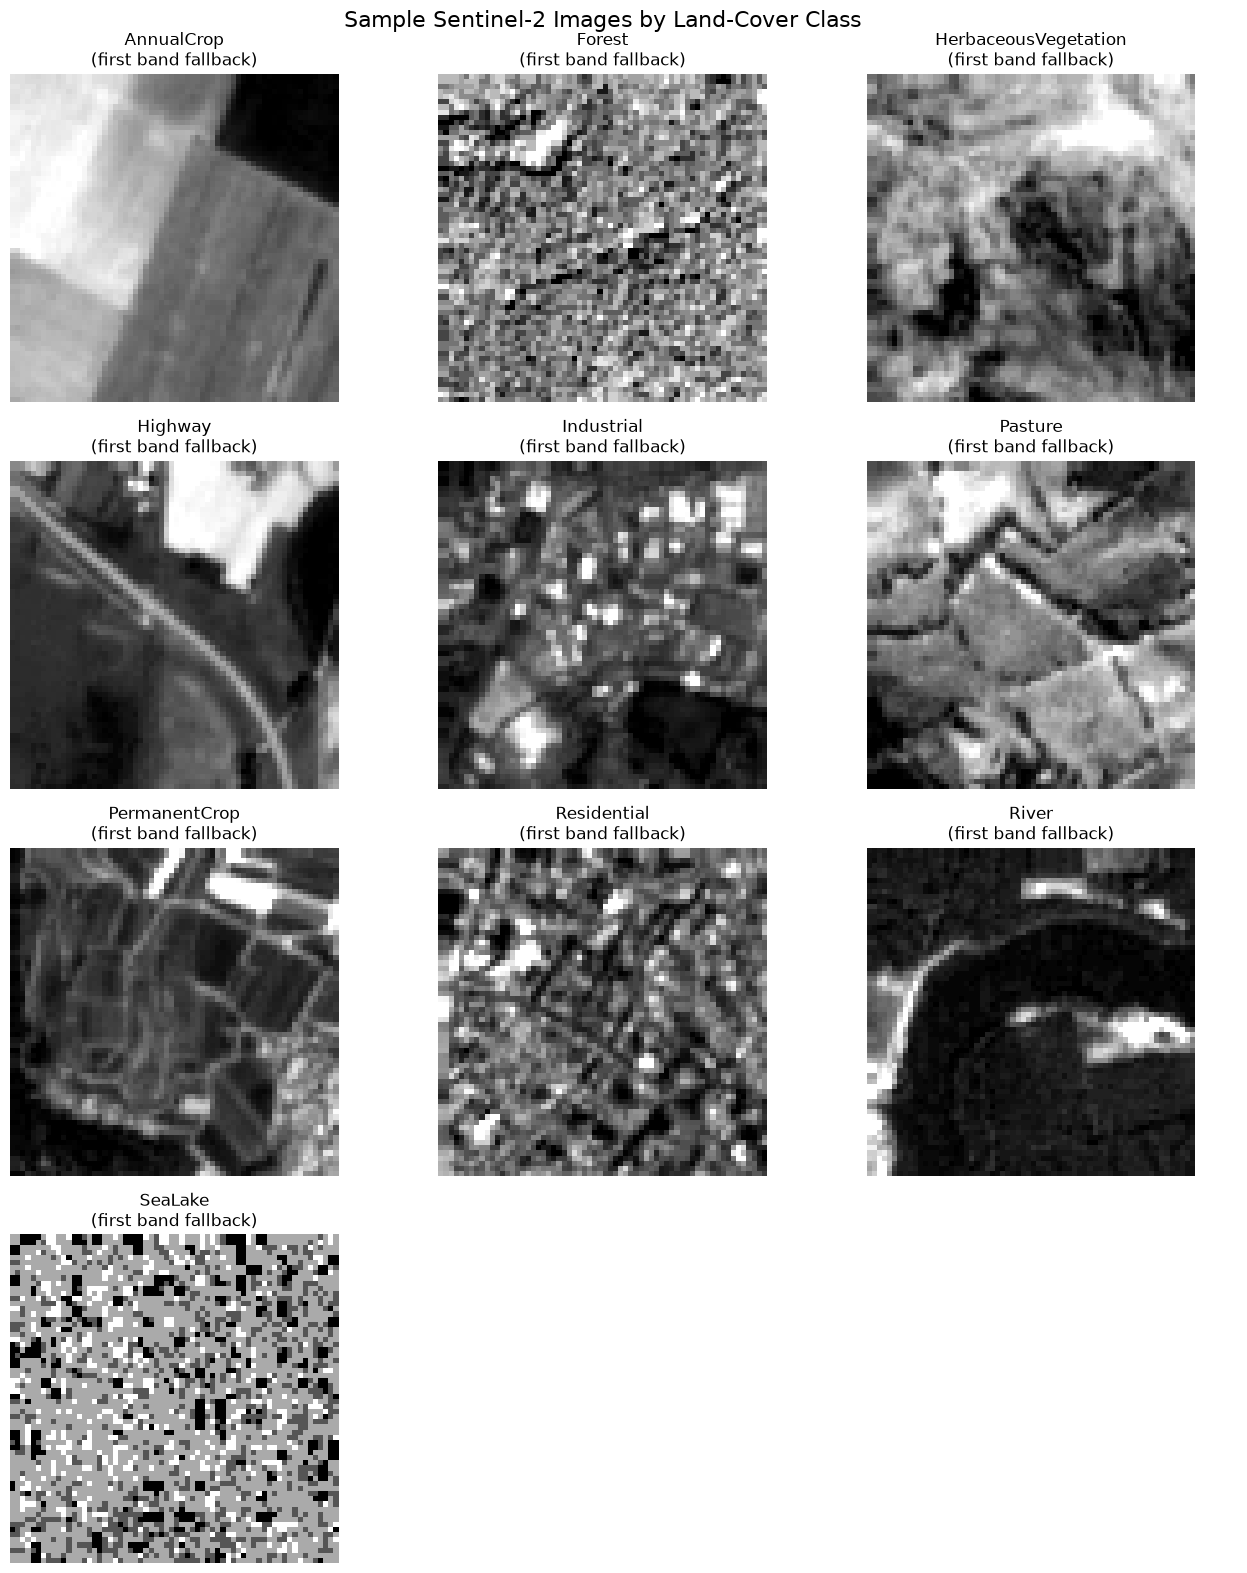

In [25]:
def percentile_stretch(img):
    img = np.asarray(img, dtype=np.float32)
    lo, hi = np.nanpercentile(img, [2, 98])
    if hi <= lo:
        return np.zeros_like(img)
    return np.clip((img - lo) / (hi - lo), 0, 1)

def rgb_from_multispectral(arr_bf):
    if arr_bf.shape[0] < 4:
        raise ValueError("At least 4 bands are required for Sentinel-2 RGB visualization.")
    # Sentinel-2: B04, B03, B02 -> indices 3, 2, 1
    rgb = np.stack([
        arr_bf[3],
        arr_bf[2],
        arr_bf[1]
    ], axis=-1)
    return percentile_stretch(rgb)

classes = sorted(df["class"].unique())
n = len(classes)

fig, axes = plt.subplots(
    nrows=int(np.ceil(n / 3)),
    ncols=3,
    figsize=(13, 4 * int(np.ceil(n / 3)))
)
axes = np.array(axes).reshape(-1)

rng = random.Random(42)

for ax, cls in zip(axes, classes):
    candidates = df.loc[df["class"] == cls, "path"].tolist()
    p = Path(rng.choice(candidates))
    arr = to_bands_first(load_multispectral(p))

    try:
        rgb = rgb_from_multispectral(arr)
        ax.imshow(rgb)
    except Exception:
        # Fallback: show the first band if RGB mapping cannot be made.
        ax.imshow(percentile_stretch(arr[0]), cmap="gray")
        ax.set_title(f"{cls}\n(first band fallback)")
    else:
        ax.set_title(cls)

    ax.axis("off")

for ax in axes[len(classes):]:
    ax.axis("off")

plt.suptitle("Sample Sentinel-2 Images by Land-Cover Class", fontsize=16)
plt.tight_layout()
plt.savefig(FIGURES / "sample_images_by_class.png", dpi=200, bbox_inches="tight")
plt.show()


## 8. Sentinel-2 band metadata

EuroSAT multispectral uses 13 Sentinel-2 bands. The wavelength values below are used only to label the spectral-signature plot.


In [26]:
BANDS = [
    ("B01", 443),
    ("B02", 490),
    ("B03", 560),
    ("B04", 665),
    ("B05", 705),
    ("B06", 740),
    ("B07", 783),
    ("B08", 842),
    ("B8A", 865),
    ("B09", 945),
    ("B10", 1375),
    ("B11", 1610),
    ("B12", 2190),
]

band_names = [b[0] for b in BANDS]
wavelengths_nm = np.array([b[1] for b in BANDS])

print("Expected Sentinel-2 bands:", len(BANDS))
print(pd.DataFrame(BANDS, columns=["band", "wavelength_nm"]))


Expected Sentinel-2 bands: 13
   band  wavelength_nm
0   B01            443
1   B02            490
2   B03            560
3   B04            665
4   B05            705
5   B06            740
6   B07            783
7   B08            842
8   B8A            865
9   B09            945
10  B10           1375
11  B11           1610
12  B12           2190


## 9. Check whether the dataset really has 13 bands

This is a critical validation before calculating spectral signatures.


In [27]:
n_bands = sample_bf.shape[0]

if n_bands == 13:
    print("PASS: 13 multispectral bands detected.")
elif n_bands == 3:
    print("WARNING: Only 3 bands detected. This looks like RGB data, so true 13-band spectral signatures cannot be calculated.")
else:
    print(f"WARNING: Detected {n_bands} bands. Verify the dataset format before continuing.")


## 10. Calculate mean spectral signatures per class

A spectral signature here means the average reflectance/value of each spectral band for all pixels belonging to a land-cover class.

We first calculate one mean value per band for each image, then average those image-level means within each class. This avoids giving a very large image disproportionate influence.


In [28]:
def image_band_means(path):
    arr = to_bands_first(load_multispectral(path))
    return np.nanmean(arr, axis=(1, 2))

signature_rows = []

for _, row in df.iterrows():
    try:
        vals = image_band_means(row["path"])
        signature_rows.append([row["class"], *vals.tolist()])
    except Exception as e:
        print("Could not read:", row["path"], "|", e)

if not signature_rows:
    raise RuntimeError("No images could be loaded for spectral analysis.")

sig_df = pd.DataFrame(signature_rows, columns=["class"] + [f"band_{i+1}" for i in range(signature_rows[0].__len__() - 1)])

mean_signatures = sig_df.groupby("class").mean(numeric_only=True)

print("Mean spectral signature table:")
display(mean_signatures)


Mean spectral signature table:


,band_1,band_2,band_3
class,,,
AnnualCrop,129.597843,120.022081,117.169636
Forest,39.359913,64.455616,75.960975
HerbaceousVegetation,98.153049,98.749313,103.943455
Highway,88.029032,96.680387,103.389063
Industrial,123.383833,125.411381,134.348082
Pasture,61.920978,88.454600,94.160579
PermanentCrop,122.107935,116.024726,114.038445
Residential,100.058339,103.786874,113.017563
River,67.035443,86.616585,96.897334


## 11. Plot spectral signatures

If the dataset has 13 bands, this produces the main figure required by the task: one curve per land-cover class.


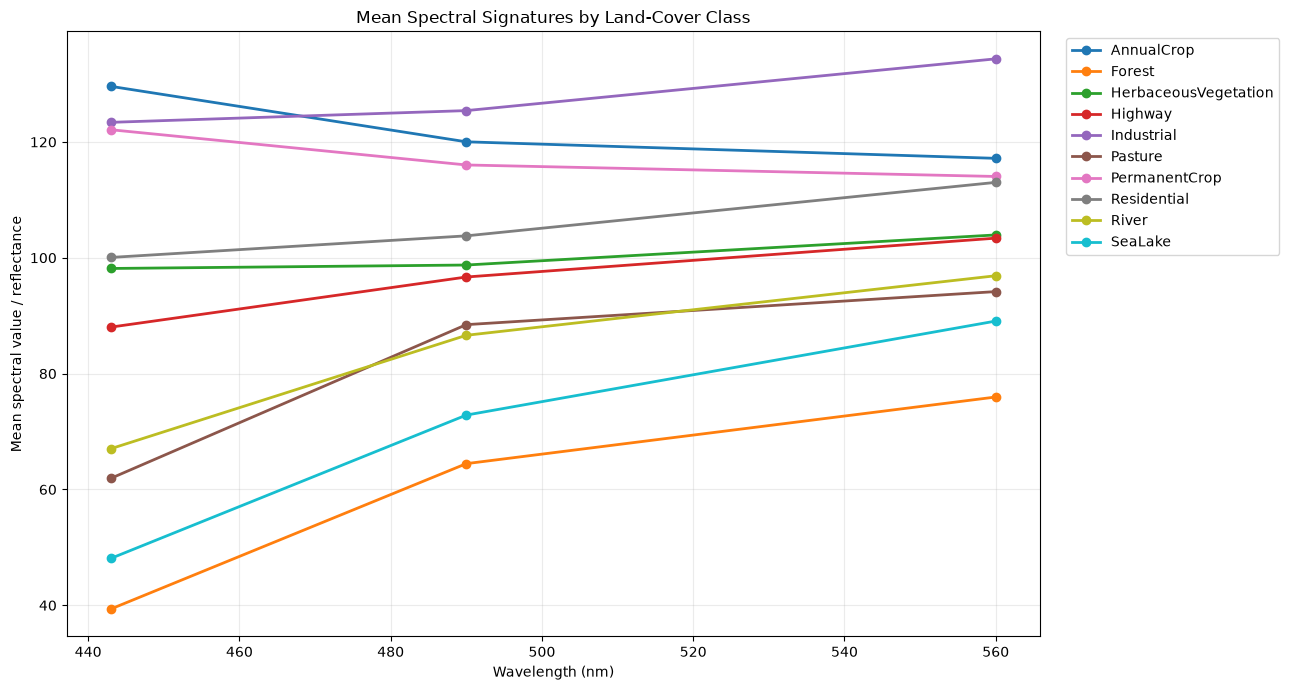

In [29]:
available_bands = mean_signatures.shape[1]
plot_band_count = min(available_bands, len(BANDS))

x = wavelengths_nm[:plot_band_count]

plt.figure(figsize=(13, 7))

for cls in mean_signatures.index:
    y = mean_signatures.loc[cls].values[:plot_band_count]
    plt.plot(x, y, marker="o", linewidth=2, label=cls)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean spectral value / reflectance")
plt.title("Mean Spectral Signatures by Land-Cover Class")
plt.grid(alpha=0.25)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES / "spectral_signatures.png", dpi=220, bbox_inches="tight")
plt.show()


## 12. Spectral variability: mean ± 1 standard deviation

The shaded/line variation helps us see whether a class has a stable spectral pattern or large within-class variability.


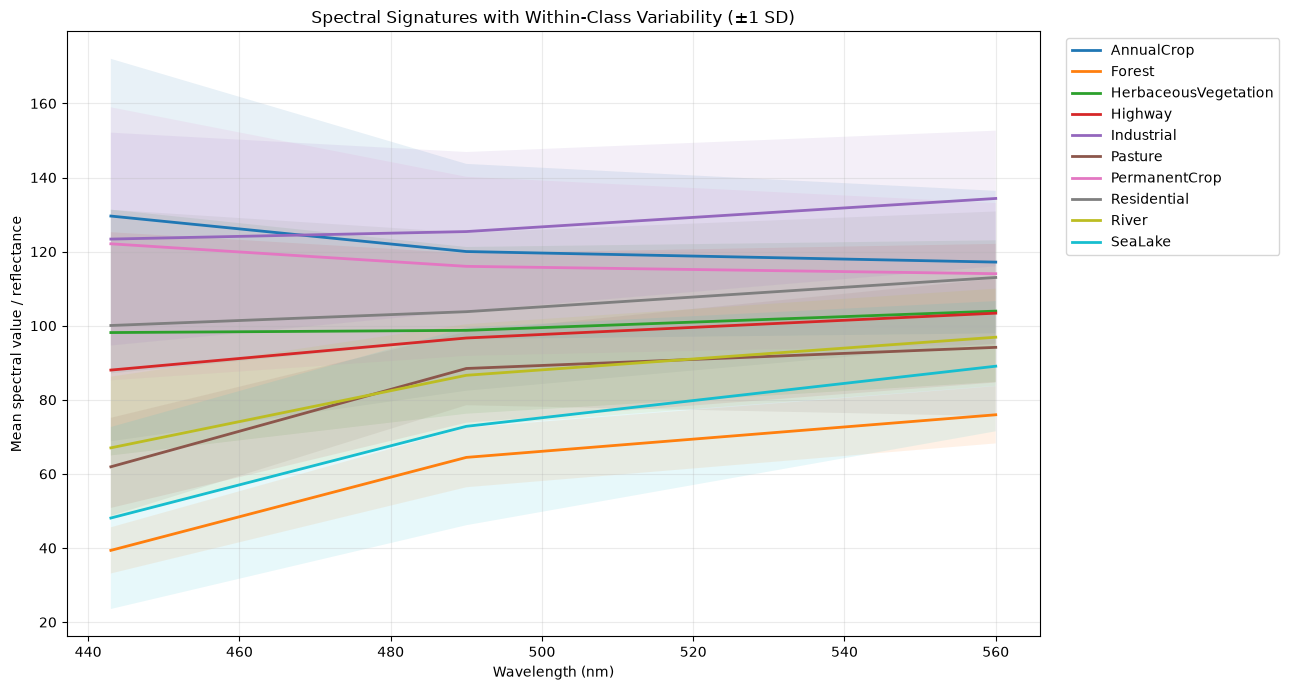

In [30]:
std_signatures = sig_df.groupby("class").std(numeric_only=True)

plt.figure(figsize=(13, 7))

for cls in mean_signatures.index:
    mean_y = mean_signatures.loc[cls].values[:plot_band_count]
    std_y = std_signatures.loc[cls].values[:plot_band_count]

    plt.plot(x, mean_y, linewidth=2, label=cls)
    plt.fill_between(x, mean_y - std_y, mean_y + std_y, alpha=0.10)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean spectral value / reflectance")
plt.title("Spectral Signatures with Within-Class Variability (±1 SD)")
plt.grid(alpha=0.25)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES / "spectral_signatures_variability.png", dpi=220, bbox_inches="tight")
plt.show()


## 13. Optional NDVI analysis

For Sentinel-2, NDVI uses:
- B08 (NIR, 842 nm)
- B04 (Red, 665 nm)

Formula:

**NDVI = (B08 − B04) / (B08 + B04)**

This section runs only when at least 8 bands are available.


In [31]:
def ndvi_from_image(arr_bf):
    if arr_bf.shape[0] < 8:
        raise ValueError("Need at least 8 bands for B08 and B04.")
    red = arr_bf[3].astype(np.float32)
    nir = arr_bf[7].astype(np.float32)
    denom = nir + red
    ndvi = np.divide(
        nir - red,
        denom,
        out=np.full_like(denom, np.nan, dtype=np.float32),
        where=denom != 0
    )
    return ndvi

if sample_bf.shape[0] >= 8:
    ndvi_records = []

    for _, row in df.iterrows():
        try:
            arr = to_bands_first(load_multispectral(row["path"]))
            ndvi = ndvi_from_image(arr)
            ndvi_records.append({
                "class": row["class"],
                "ndvi_mean": float(np.nanmean(ndvi)),
                "ndvi_std": float(np.nanstd(ndvi))
            })
        except Exception:
            pass

    ndvi_df = pd.DataFrame(ndvi_records)

    if not ndvi_df.empty:
        ndvi_summary = ndvi_df.groupby("class")["ndvi_mean"].agg(["mean", "std", "count"])
        display(ndvi_summary)

        plt.figure(figsize=(11, 6))
        ndvi_df.boxplot(column="ndvi_mean", by="class", grid=False)
        plt.suptitle("")
        plt.title("NDVI Distribution by Land-Cover Class")
        plt.xlabel("Land-cover class")
        plt.ylabel("Mean NDVI per image")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(FIGURES / "ndvi_distribution.png", dpi=200, bbox_inches="tight")
        plt.show()
else:
    print("NDVI section skipped because fewer than 8 bands were detected.")


NDVI section skipped because fewer than 8 bands were detected.


## 14. Automatic findings table

The next cell generates numerical findings that can be used in the report. **Do not write generic observations before seeing these results.**


In [32]:
# Identify the most variable bands across classes.
class_means = mean_signatures.copy()
between_class_std = class_means.std(axis=0).sort_values(ascending=False)

findings = pd.DataFrame({
    "metric": [
        "number_of_classes",
        "total_samples",
        "detected_bands",
        "most_separating_band_by_class_mean_std"
    ],
    "value": [
        int(df["class"].nunique()),
        int(len(df)),
        int(n_bands),
        between_class_std.index[0] if len(between_class_std) else "N/A"
    ]
})

display(findings)


,metric,value
0,number_of_classes,10
1,total_samples,27000
2,detected_bands,3
3,most_separating_band_by_class_mean_std,band_1


## 15. Export the analysis tables

These CSV files are useful as evidence for the report and for the next project stages.


In [33]:
class_counts.to_csv(PROJECT_ROOT / "data" / "interim" / "class_distribution.csv", index=False)
mean_signatures.to_csv(PROJECT_ROOT / "data" / "interim" / "mean_spectral_signatures.csv")
std_signatures.to_csv(PROJECT_ROOT / "data" / "interim" / "std_spectral_signatures.csv")

print("Saved:")
print("-", PROJECT_ROOT / "data" / "interim" / "class_distribution.csv")
print("-", PROJECT_ROOT / "data" / "interim" / "mean_spectral_signatures.csv")
print("-", PROJECT_ROOT / "data" / "interim" / "std_spectral_signatures.csv")


Saved:
- c:\Users\HP\Downloads\satellite_empty\data\interim\class_distribution.csv
- c:\Users\HP\Downloads\satellite_empty\data\interim\mean_spectral_signatures.csv
- c:\Users\HP\Downloads\satellite_empty\data\interim\std_spectral_signatures.csv


# Final checklist for this task

Before moving to preprocessing/modeling, verify that:

- [ ] The raw dataset is inside `data/raw/`.
- [ ] The notebook detects the expected classes.
- [ ] Class counts are displayed and saved.
- [ ] One RGB composite sample is shown for every class.
- [ ] The number of spectral bands is verified.
- [ ] Mean spectral signatures are calculated.
- [ ] `spectral_signatures.png` is saved in `reports/figures/`.
- [ ] Spectral variability is calculated.
- [ ] NDVI is calculated only when the required bands exist.
- [ ] Findings are based on the actual dataset output, not assumptions.
- [ ] No raw files were modified.


In [37]:
## 16. Multispectral Spectral Signature Analysis
from pathlib import Path

ROOT = Path.cwd().parent

matches = list(ROOT.rglob("EuroSAT_MS"))

print("Found:")
for path in matches:
    print(path)

Found:
c:\Users\HP\Downloads\satellite_empty\EuroSAT_MS
c:\Users\HP\Downloads\satellite_empty\EuroSAT_MS\EuroSAT_MS


In [38]:
from pathlib import Path

ROOT = Path.cwd().parent

MS_DIR = ROOT / "EuroSAT_MS" / "EuroSAT_MS"

print("MS_DIR:", MS_DIR)
print("Exists:", MS_DIR.exists())

MS_DIR: c:\Users\HP\Downloads\satellite_empty\EuroSAT_MS\EuroSAT_MS
Exists: True


In [39]:
for item in MS_DIR.iterdir():
    print(item.name, "DIR" if item.is_dir() else "FILE")

AnnualCrop DIR
Forest DIR
HerbaceousVegetation DIR
Highway DIR
Industrial DIR
Pasture DIR
PermanentCrop DIR
Residential DIR
River DIR
SeaLake DIR


In [41]:
%pip install rasterio

   ---------------------------------------- 0.0/31.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/31.5 MB ? eta -:--:--
    --------------------------------------- 0.5/31.5 MB 1.4 MB/s eta 0:00:23
    --------------------------------------- 0.5/31.5 MB 1.4 MB/s eta 0:00:23
    --------------------------------------- 0.5/31.5 MB 1.4 MB/s eta 0:00:23
    --------------------------------------- 0.8/31.5 MB 567.9 kB/s eta 0:00:55
    --------------------------------------- 0.8/31.5 MB 567.9 kB/s eta 0:00:55
    --------------------------------------- 0.8/31.5 MB 567.9 kB/s eta 0:00:55
    --------------------------------------- 0.8/31.5 MB 567.9 kB/s eta 0:00:55
    --------------------------------------- 0.8/31.5 MB 567.9 kB/s eta 0:00:55
    --------------------------------------- 0.8/31.5 MB 567.9 kB/s eta 0:00:55
    -----------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from pathlib import Path

print("All imports are ready.")

All imports are ready.


In [43]:
records_ms = []

supported_extensions = {".tif", ".tiff"}

for class_dir in sorted(MS_DIR.iterdir()):
    if class_dir.is_dir():

        label = class_dir.name

        for f in sorted(class_dir.iterdir()):
            if f.is_file() and f.suffix.lower() in supported_extensions:
                records_ms.append({
                    "path": str(f),
                    "class": label
                })

df_ms = pd.DataFrame(records_ms)

print("Total multispectral images:", len(df_ms))
print("Number of classes:", df_ms["class"].nunique())

print("\nClasses:")
print(sorted(df_ms["class"].unique()))

Total multispectral images: 27000
Number of classes: 10

Classes:
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [44]:
sample_path = Path(df_ms.iloc[0]["path"])

with rasterio.open(sample_path) as src:
    sample_ms = src.read()

print("Sample:", sample_path)
print("Shape:", sample_ms.shape)
print("Dtype:", sample_ms.dtype)
print("Min:", sample_ms.min())
print("Max:", sample_ms.max())

Sample: c:\Users\HP\Downloads\satellite_empty\EuroSAT_MS\EuroSAT_MS\AnnualCrop\AnnualCrop_1.tif
Shape: (13, 64, 64)
Dtype: uint16
Min: 9
Max: 3490


In [45]:
bands = [
    "B01", "B02", "B03", "B04", "B05",
    "B06", "B07", "B08", "B8A", "B09",
    "B10", "B11", "B12"
]

wavelengths = [
    443, 490, 560, 665, 705,
    740, 783, 842, 865, 945,
    1375, 1610, 2190
]

band_info = pd.DataFrame({
    "Band": bands,
    "Wavelength_nm": wavelengths
})

band_info

,Band,Wavelength_nm
0,B01,443
1,B02,490
2,B03,560
3,B04,665
4,B05,705
5,B06,740
6,B07,783
7,B08,842
8,B8A,865
9,B09,945


In [46]:
class_band_means = {}

for class_name in sorted(df_ms["class"].unique()):

    print(f"Processing: {class_name}")

    class_files = df_ms[
        df_ms["class"] == class_name
    ]["path"]

    all_band_means = []

    for file_path in class_files:

        with rasterio.open(file_path) as src:
            image = src.read().astype(np.float32)

        # Mean value for each of the 13 bands
        band_means = image.mean(axis=(1, 2))

        all_band_means.append(band_means)

    # Convert list to NumPy array
    all_band_means = np.array(all_band_means)

    # Mean across all images in this class
    class_mean = all_band_means.mean(axis=0)

    class_band_means[class_name] = class_mean

print("\nSpectral signatures calculated successfully!")

Processing: AnnualCrop
Processing: Forest
Processing: HerbaceousVegetation
Processing: Highway
Processing: Industrial
Processing: Pasture
Processing: PermanentCrop
Processing: Residential
Processing: River
Processing: SeaLake

Spectral signatures calculated successfully!


In [47]:
spectral_df = pd.DataFrame(
    class_band_means,
    index=bands
).T

spectral_df.index.name = "Class"

spectral_df.round(2)

,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B09,B10,B11,B12
Class,,,,,,,,,,,,,
AnnualCrop,1415.449951,1257.689941,1288.569946,1403.119995,1692.599976,2663.979980,3189.280029,3086.659912,846.409973,13.400000,2657.500000,1692.880005,3531.110107
Forest,1110.530029,811.809998,687.380005,415.429993,747.789978,2100.560059,2690.189941,2636.090088,823.960022,9.910000,1313.750000,535.409973,3007.879883
HerbaceousVegetation,1324.290039,1114.510010,1058.500000,1053.619995,1371.770020,2062.129883,2360.070068,2369.169922,1052.199951,16.469999,2345.560059,1441.609985,2654.840088
Highway,1349.699951,1109.550049,1037.290039,947.659973,1230.619995,2168.260010,2586.689941,2510.100098,791.659973,12.130000,1958.060059,1196.040039,2840.580078
Industrial,1665.199951,1466.280029,1372.060059,1367.300049,1512.199951,2002.369995,2238.419922,2120.590088,633.729980,12.280000,2056.159912,1503.420044,2381.320068
Pasture,1295.400024,1008.280029,946.780029,659.809998,1176.280029,2797.370117,3450.310059,3394.979980,1114.800049,12.930000,1972.609985,951.369995,3843.370117
PermanentCrop,1412.640015,1224.140015,1245.530029,1315.290039,1603.469971,2457.040039,2870.110107,2779.639893,812.440002,13.580000,2693.100098,1756.410034,3158.739990
Residential,1458.290039,1213.699951,1114.119995,1075.489990,1288.170044,1981.020020,2287.280029,2187.260010,665.539978,12.290000,1974.959961,1382.510010,2469.959961
River,1304.969971,1038.579956,927.500000,716.010010,932.460022,1718.989990,2073.050049,1992.369995,597.559998,10.540000,1305.880005,721.739990,2247.659912


In [48]:
spectral_df = pd.DataFrame(
    class_band_means,
    index=bands
).T

spectral_df.index.name = "Class"

spectral_df.round(2)

,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B09,B10,B11,B12
Class,,,,,,,,,,,,,
AnnualCrop,1415.449951,1257.689941,1288.569946,1403.119995,1692.599976,2663.979980,3189.280029,3086.659912,846.409973,13.400000,2657.500000,1692.880005,3531.110107
Forest,1110.530029,811.809998,687.380005,415.429993,747.789978,2100.560059,2690.189941,2636.090088,823.960022,9.910000,1313.750000,535.409973,3007.879883
HerbaceousVegetation,1324.290039,1114.510010,1058.500000,1053.619995,1371.770020,2062.129883,2360.070068,2369.169922,1052.199951,16.469999,2345.560059,1441.609985,2654.840088
Highway,1349.699951,1109.550049,1037.290039,947.659973,1230.619995,2168.260010,2586.689941,2510.100098,791.659973,12.130000,1958.060059,1196.040039,2840.580078
Industrial,1665.199951,1466.280029,1372.060059,1367.300049,1512.199951,2002.369995,2238.419922,2120.590088,633.729980,12.280000,2056.159912,1503.420044,2381.320068
Pasture,1295.400024,1008.280029,946.780029,659.809998,1176.280029,2797.370117,3450.310059,3394.979980,1114.800049,12.930000,1972.609985,951.369995,3843.370117
PermanentCrop,1412.640015,1224.140015,1245.530029,1315.290039,1603.469971,2457.040039,2870.110107,2779.639893,812.440002,13.580000,2693.100098,1756.410034,3158.739990
Residential,1458.290039,1213.699951,1114.119995,1075.489990,1288.170044,1981.020020,2287.280029,2187.260010,665.539978,12.290000,1974.959961,1382.510010,2469.959961
River,1304.969971,1038.579956,927.500000,716.010010,932.460022,1718.989990,2073.050049,1992.369995,597.559998,10.540000,1305.880005,721.739990,2247.659912


In [49]:
print("Shape:", spectral_df.shape)
print("Rows (classes):", spectral_df.index.tolist())
print("Columns (bands):", spectral_df.columns.tolist())
print("Missing values:", spectral_df.isna().sum().sum())

Shape: (10, 13)
Rows (classes): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Columns (bands): ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B10', 'B11', 'B12']
Missing values: 0


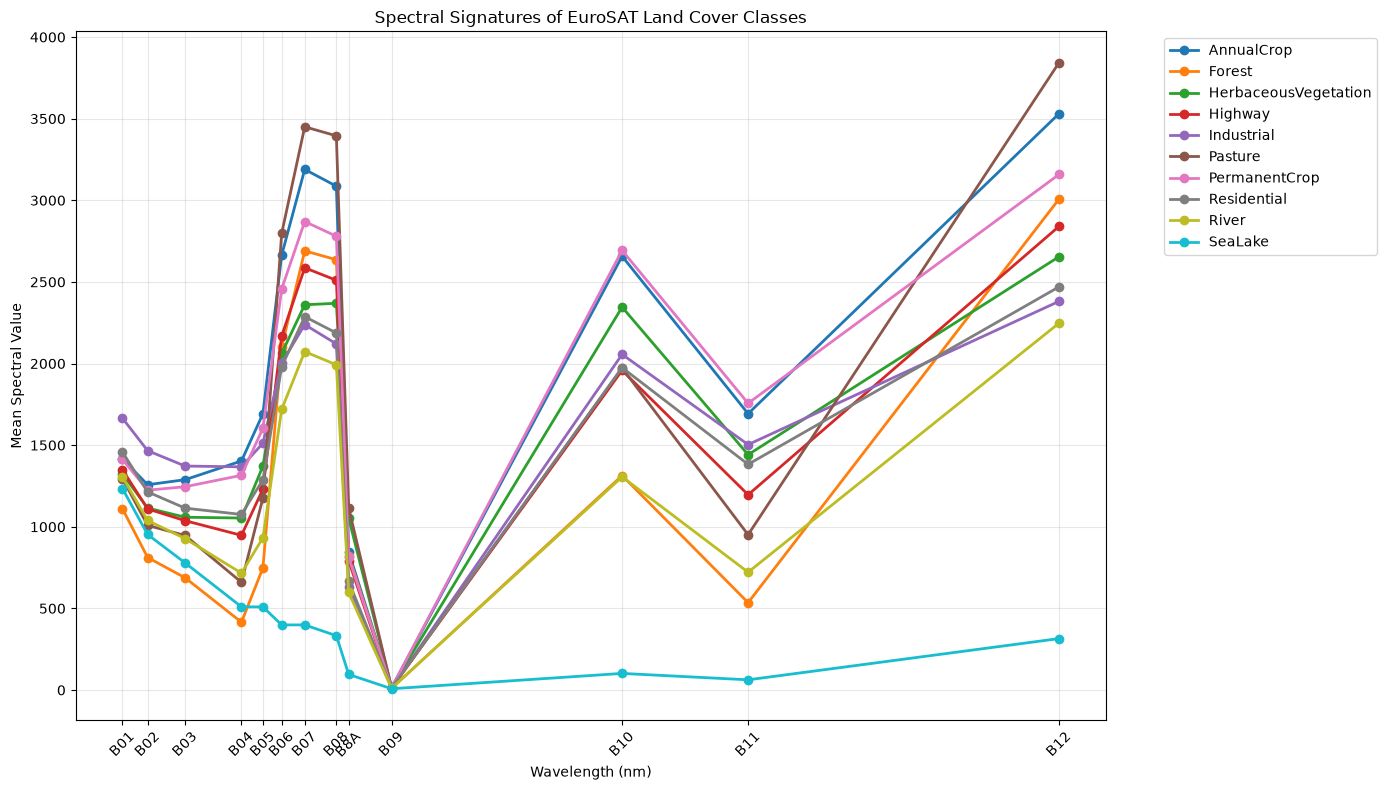

In [50]:
plt.figure(figsize=(14, 8))

for class_name in spectral_df.index:
    plt.plot(
        wavelengths,
        spectral_df.loc[class_name].values,
        marker="o",
        linewidth=2,
        label=class_name
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean Spectral Value")
plt.title("Spectral Signatures of EuroSAT Land Cover Classes")

plt.xticks(wavelengths, bands, rotation=45)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

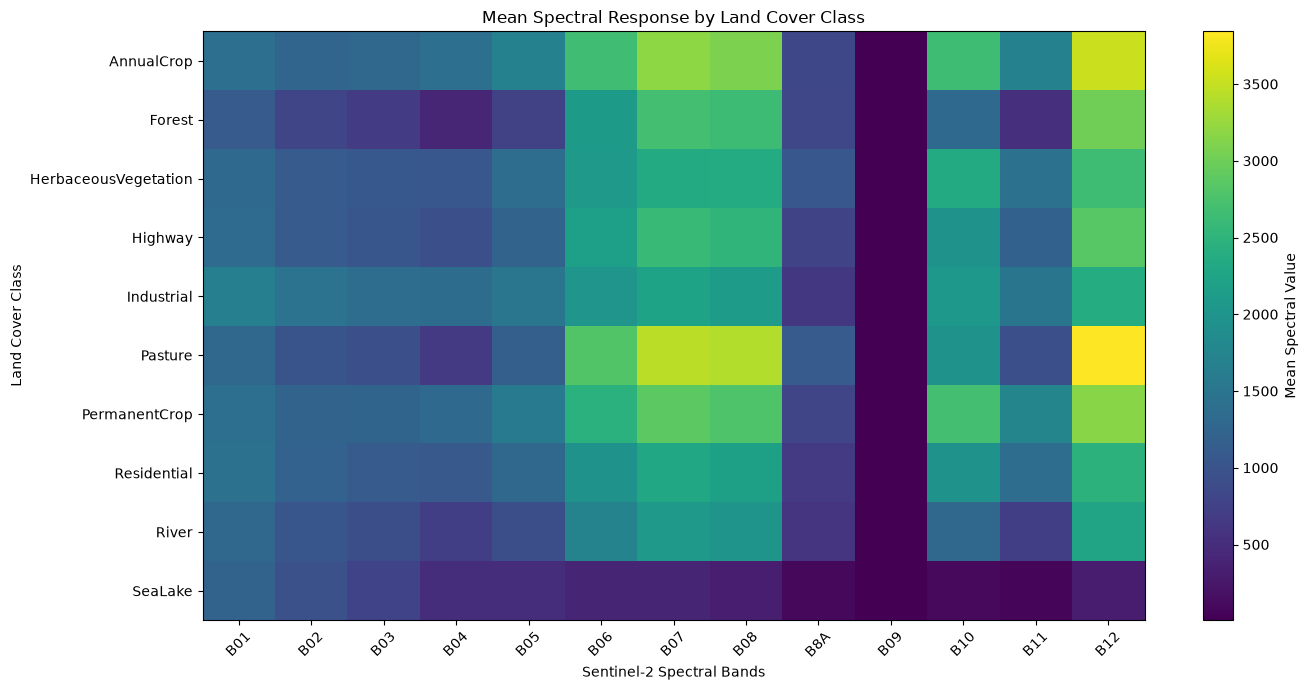

In [51]:
plt.figure(figsize=(14, 7))

plt.imshow(
    spectral_df.values,
    aspect="auto"
)

plt.colorbar(label="Mean Spectral Value")

plt.xticks(
    range(len(bands)),
    bands,
    rotation=45
)

plt.yticks(
    range(len(spectral_df.index)),
    spectral_df.index
)

plt.xlabel("Sentinel-2 Spectral Bands")
plt.ylabel("Land Cover Class")
plt.title("Mean Spectral Response by Land Cover Class")

plt.tight_layout()

plt.show()

In [52]:
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

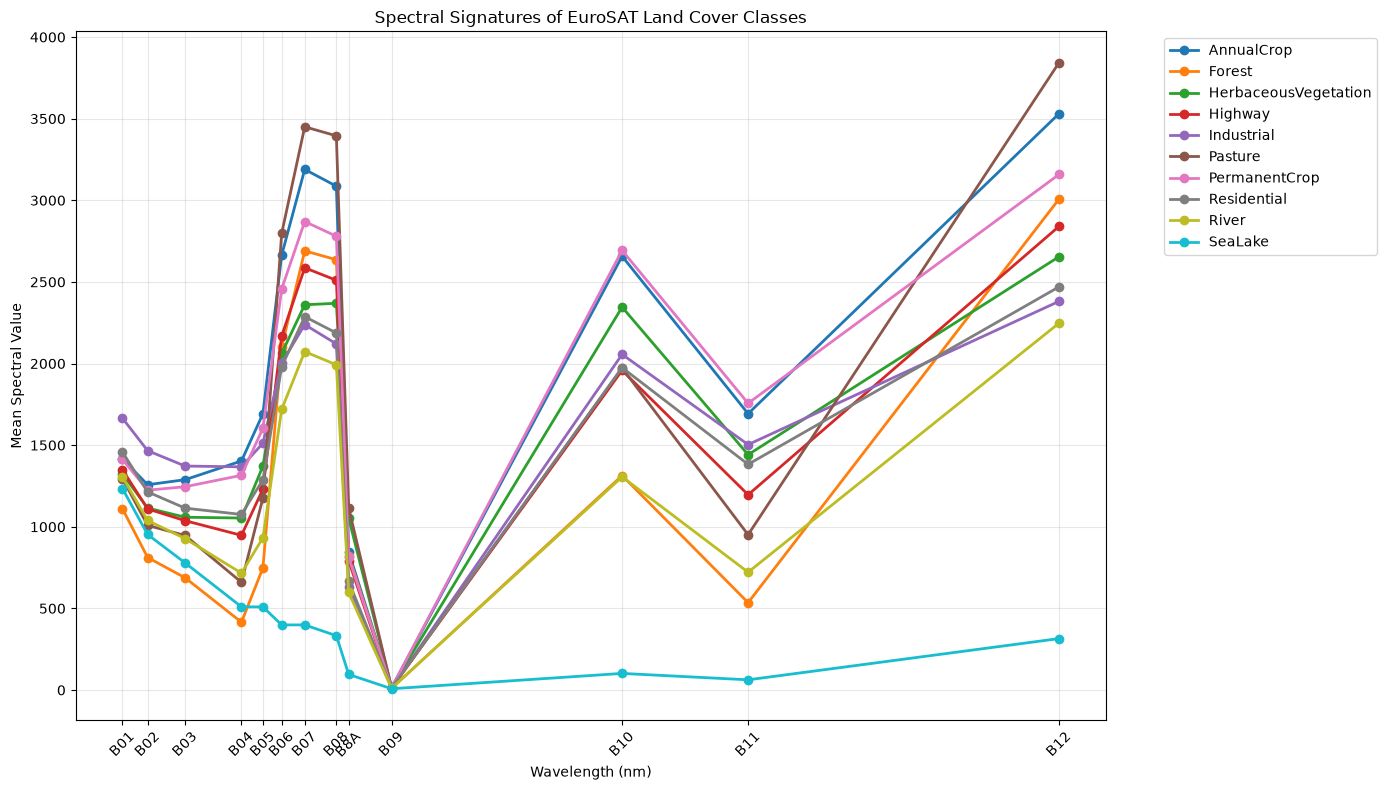

In [53]:
plt.figure(figsize=(14, 8))

for class_name in spectral_df.index:
    plt.plot(
        wavelengths,
        spectral_df.loc[class_name].values,
        marker="o",
        linewidth=2,
        label=class_name
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean Spectral Value")
plt.title("Spectral Signatures of EuroSAT Land Cover Classes")

plt.xticks(wavelengths, bands, rotation=45)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "spectral_signatures.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [54]:
spectral_df.round(2).to_csv(
    OUTPUT_DIR / "spectral_signatures_by_class.csv"
)

print("Spectral signature table saved successfully.")

Spectral signature table saved successfully.


In [55]:
band_info.to_csv(
    OUTPUT_DIR / "sentinel2_band_information.csv",
    index=False
)

print("Band information saved successfully.")

Band information saved successfully.


In [56]:
ndvi_by_class = {}

for class_name in sorted(df_ms["class"].unique()):

    print(f"Processing NDVI: {class_name}")

    class_files = df_ms[
        df_ms["class"] == class_name
    ]["path"]

    ndvi_values = []

    for file_path in class_files:

        with rasterio.open(file_path) as src:
            image = src.read().astype(np.float32)

        red = image[3]
        nir = image[7]

        ndvi = (nir - red) / (nir + red + 1e-8)

        ndvi_values.append(ndvi.mean())

    ndvi_by_class[class_name] = np.mean(ndvi_values)

print("NDVI calculation completed!")

Processing NDVI: AnnualCrop
Processing NDVI: Forest
Processing NDVI: HerbaceousVegetation
Processing NDVI: Highway
Processing NDVI: Industrial
Processing NDVI: Pasture
Processing NDVI: PermanentCrop
Processing NDVI: Residential
Processing NDVI: River
Processing NDVI: SeaLake
NDVI calculation completed!


In [57]:
ndvi_df = pd.DataFrame(
    list(ndvi_by_class.items()),
    columns=["Class", "Mean_NDVI"]
)

ndvi_df = ndvi_df.sort_values(
    "Mean_NDVI",
    ascending=False
)

ndvi_df.round(3)

,Class,Mean_NDVI
1,Forest,0.713
5,Pasture,0.654
3,Highway,0.446
2,HerbaceousVegetation,0.385
0,AnnualCrop,0.376
6,PermanentCrop,0.372
7,Residential,0.340
8,River,0.327
4,Industrial,0.223
9,SeaLake,-0.253


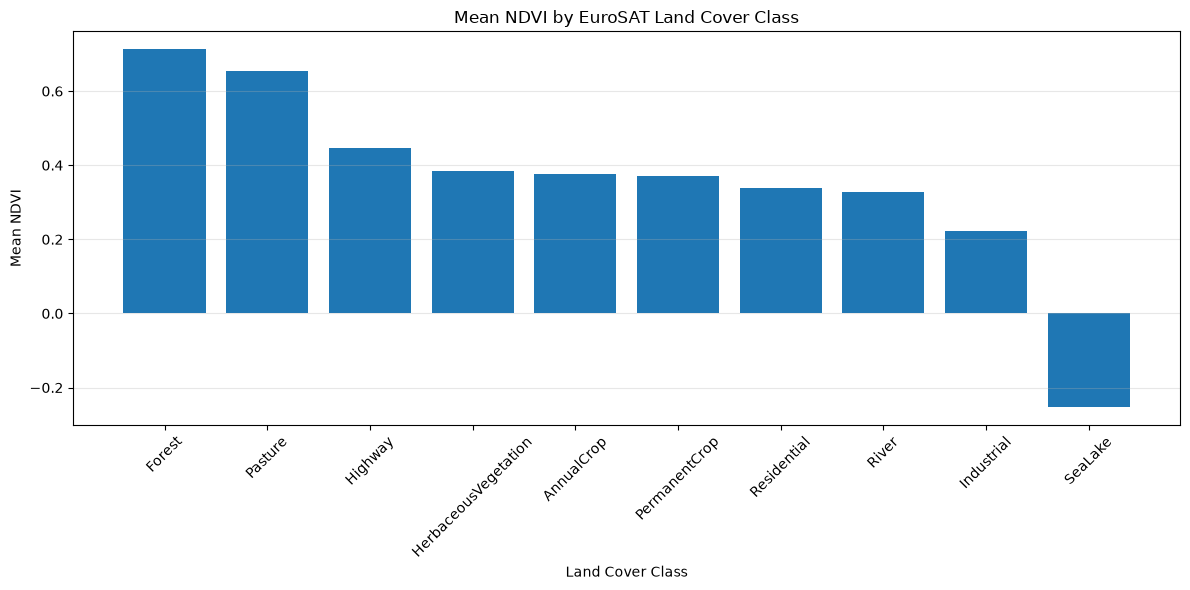

In [58]:
plt.figure(figsize=(12, 6))

plt.bar(
    ndvi_df["Class"],
    ndvi_df["Mean_NDVI"]
)

plt.xlabel("Land Cover Class")
plt.ylabel("Mean NDVI")
plt.title("Mean NDVI by EuroSAT Land Cover Class")

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [59]:
plt.savefig(
    OUTPUT_DIR / "ndvi_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

ndvi_df.to_csv(
    OUTPUT_DIR / "ndvi_by_class.csv",
    index=False
)

<Figure size 640x480 with 0 Axes>